#### Student Performance Indicator

##### Life cycle of Machine learning Project

* Undestanding the problems Statement
* Date colletion
* Date checks to perform
* Date Pre-Processing
* Model Training
* Choose best model

#### 1.Problem statement
* This project understanding how the student's performance (test-score) is affected by other variables such as Gender,Ethnicity,Parent level of education,Lunch and test preparation course.

#### 2.Date collection
* Date source -
* The date consists of 8 columns and 1000 rows

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### import the csv data as pandas dataframe

In [3]:
df = pd.read_csv('stud.csv')
df.head()


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Exploring Data


In [10]:
df.head()


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
print("Categories in 'gender' variable:    ",end=" ")
print(df['gender'].unique())

print("Categories in 'race_ethinicity ' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of educatin ' variable: ",end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch ' vari€bale:  ",end= " ")
print(df['lunch'].unique())

print("Categories in 'test preparation course ' variable: ",end= " ")
print(df['test_preparation_course'].unique())
      



Categories in 'gender' variable:     ['female' 'male']
Categories in 'race_ethinicity ' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of educatin ' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch ' vari€bale:   ['standard' 'free/reduced']
Categories in 'test preparation course ' variable:  ['none' 'completed']


In [12]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [13]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
# Total score and Average both are adding
df['total score'] = df['math_score'] + df['reading_score']+ df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
reading_full = df[df['reading_score'] == 100]['average'].count()
print(reading_full)
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100 ]['average'].count()

print(f'Number of students with full marks in maths: {math_full}')
print(f'Number of student with full marks in writing : {writing_full}')
print(f'Number of student with full marks in Reading : {reading_full}')

17
Number of students with full marks in maths: 7
Number of student with full marks in writing : 14
Number of student with full marks in Reading : 17


In [16]:
reading_less_20 = df[df['reading_score'] <=20]['average'].count()
writing_less_20 = df[df['writing_score']<=20]['average'].count()
math_less_20 = df[df['math_score']<=20]['average'].count()

print(f'Number of students with less than 20 marks in maths : {math_less_20}')
print(f'Number of students with less than 20 marks in Writing : {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading : {reading_less_20}')



Number of students with less than 20 marks in maths : 4
Number of students with less than 20 marks in Writing : 3
Number of students with less than 20 marks in Reading : 1


#### Exploring Data(Visualization)

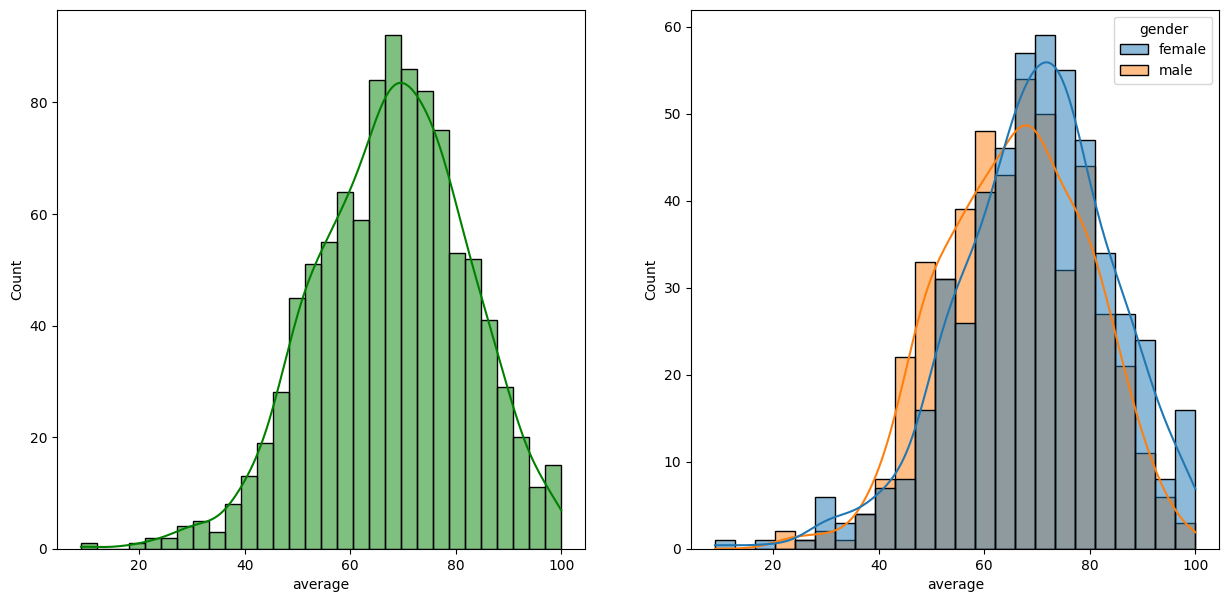

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

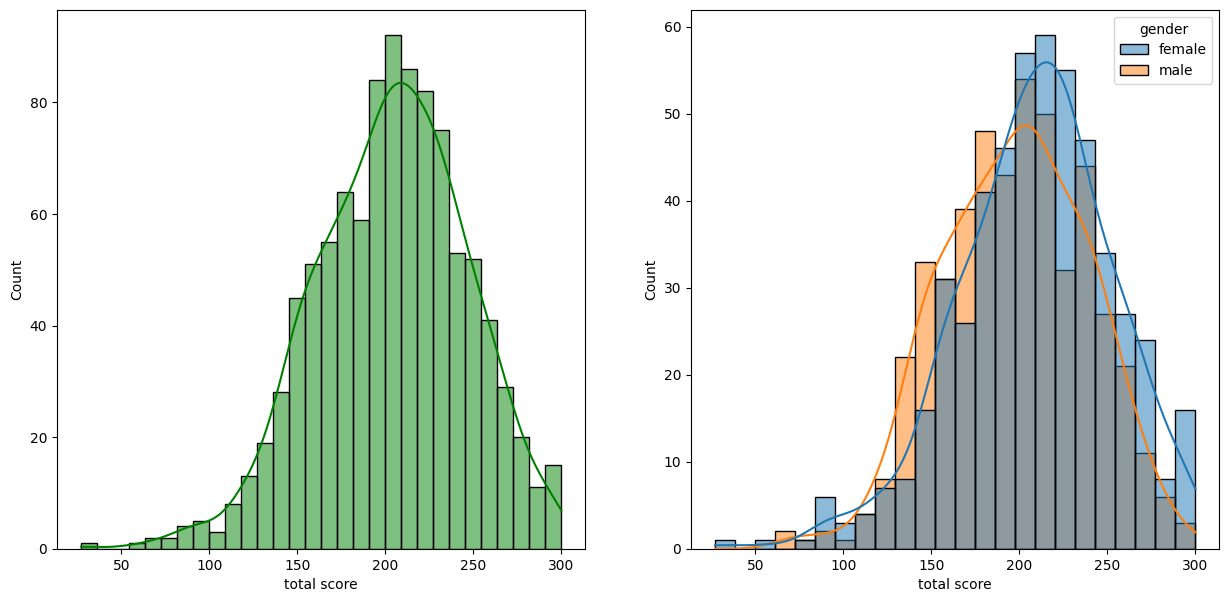

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

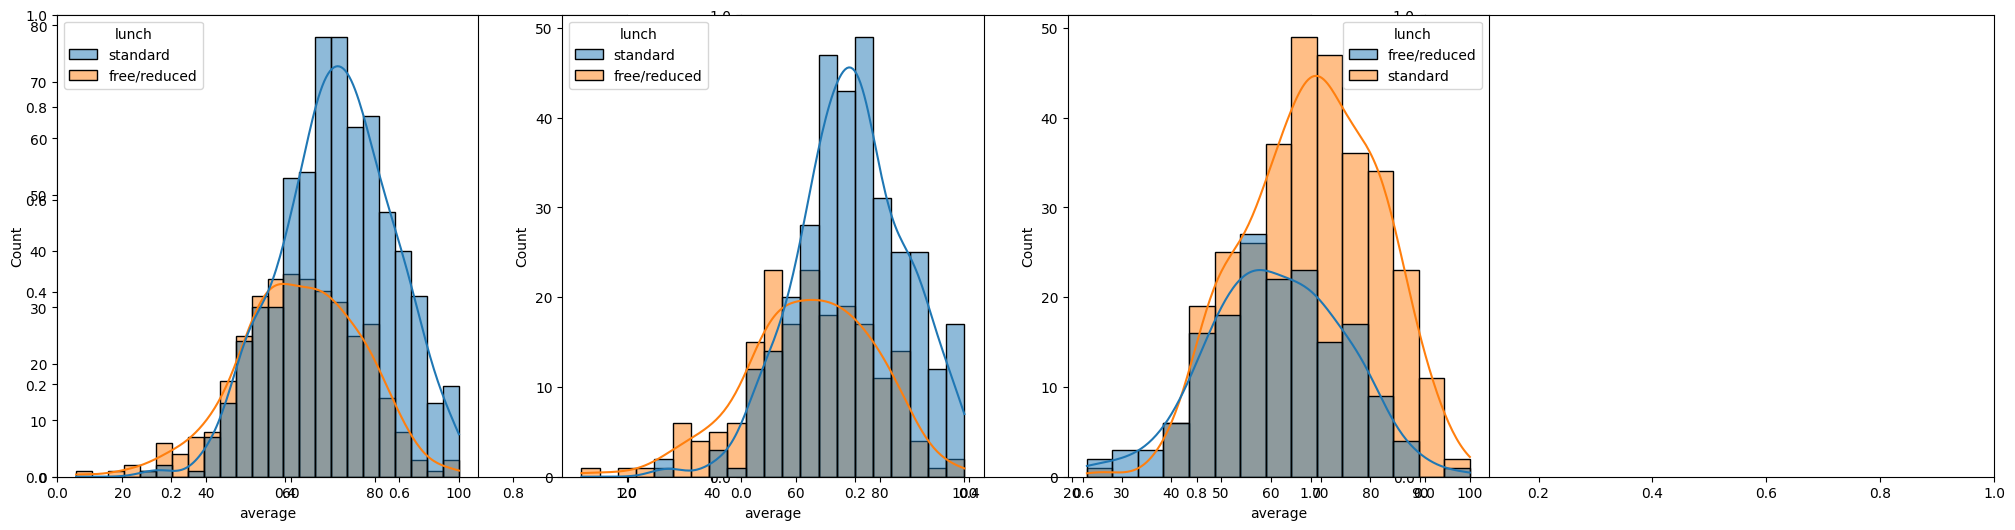

In [19]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

In [20]:
# Check all columns
print(df.columns.tolist())

# If you have many columns, search for columns containing 'parent' or 'education'
parent_cols = [col for col in df.columns if 'parent' in col.lower() or 'education' in col.lower()]
print("Potential parent/education columns:", parent_cols)

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'total score', 'average']
Potential parent/education columns: ['parental_level_of_education']


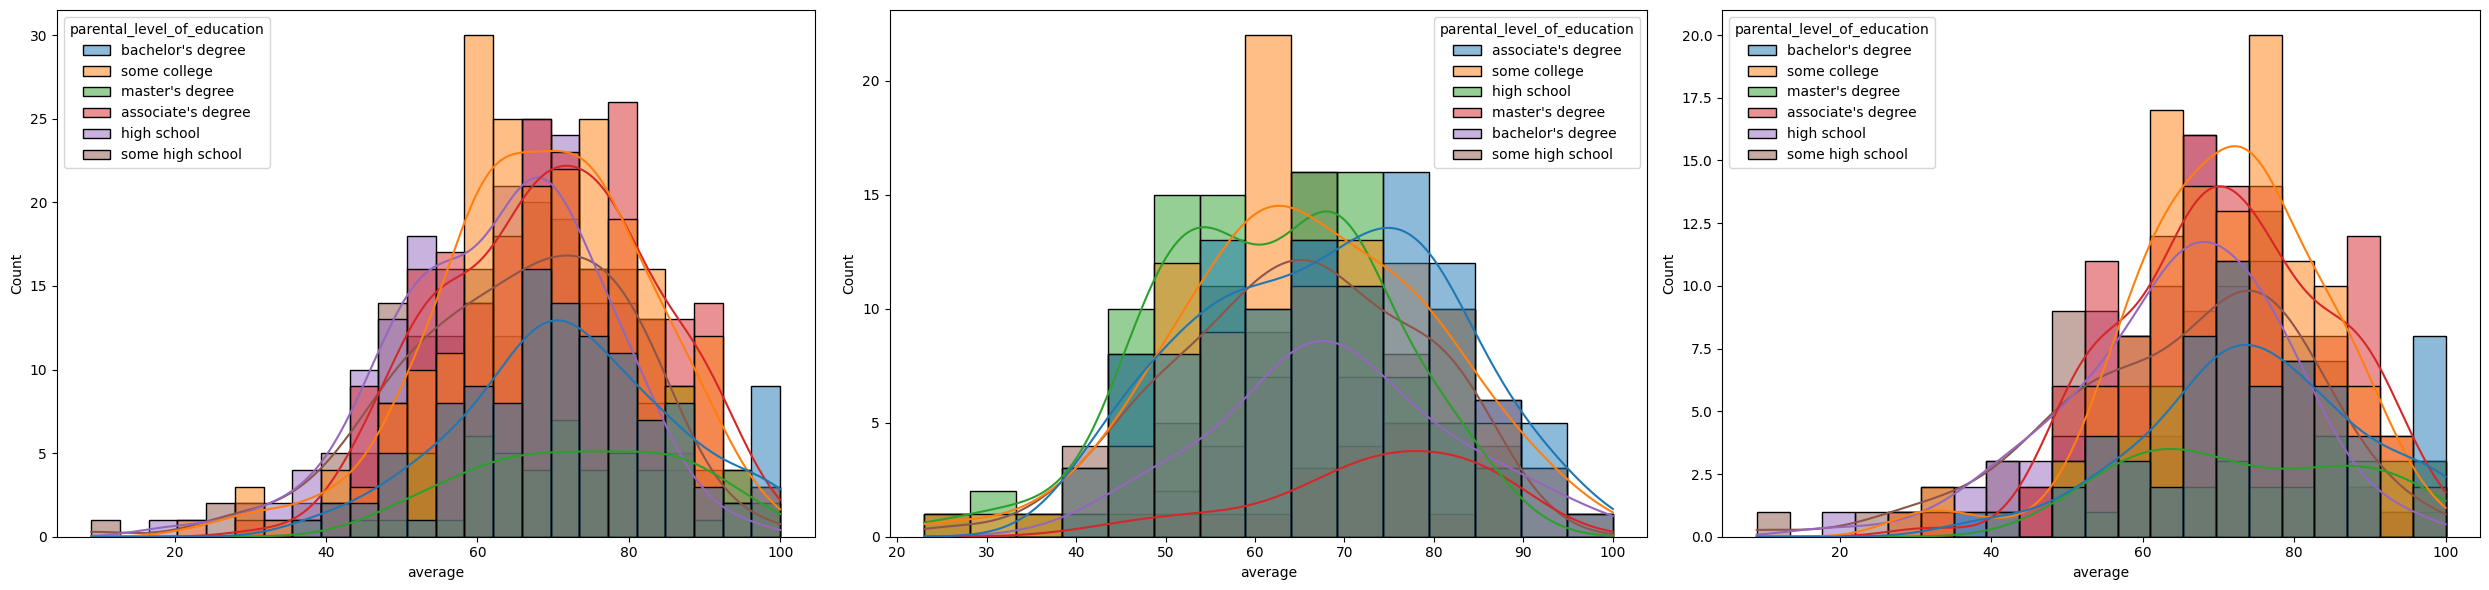

In [22]:

correct_column = 'parental_level_of_education'  

fig, axes = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df, x='average', kde=True, hue=correct_column, ax=axes[0])
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue=correct_column, ax=axes[1])
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue=correct_column, ax=axes[2])

plt.tight_layout()
plt.show()


##### Insights
1.In genral parent's education dont's help student perform well in exam

2.2nd plot show that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam

3.3rd plot we can see there is no effect of parent's education om female studemts.








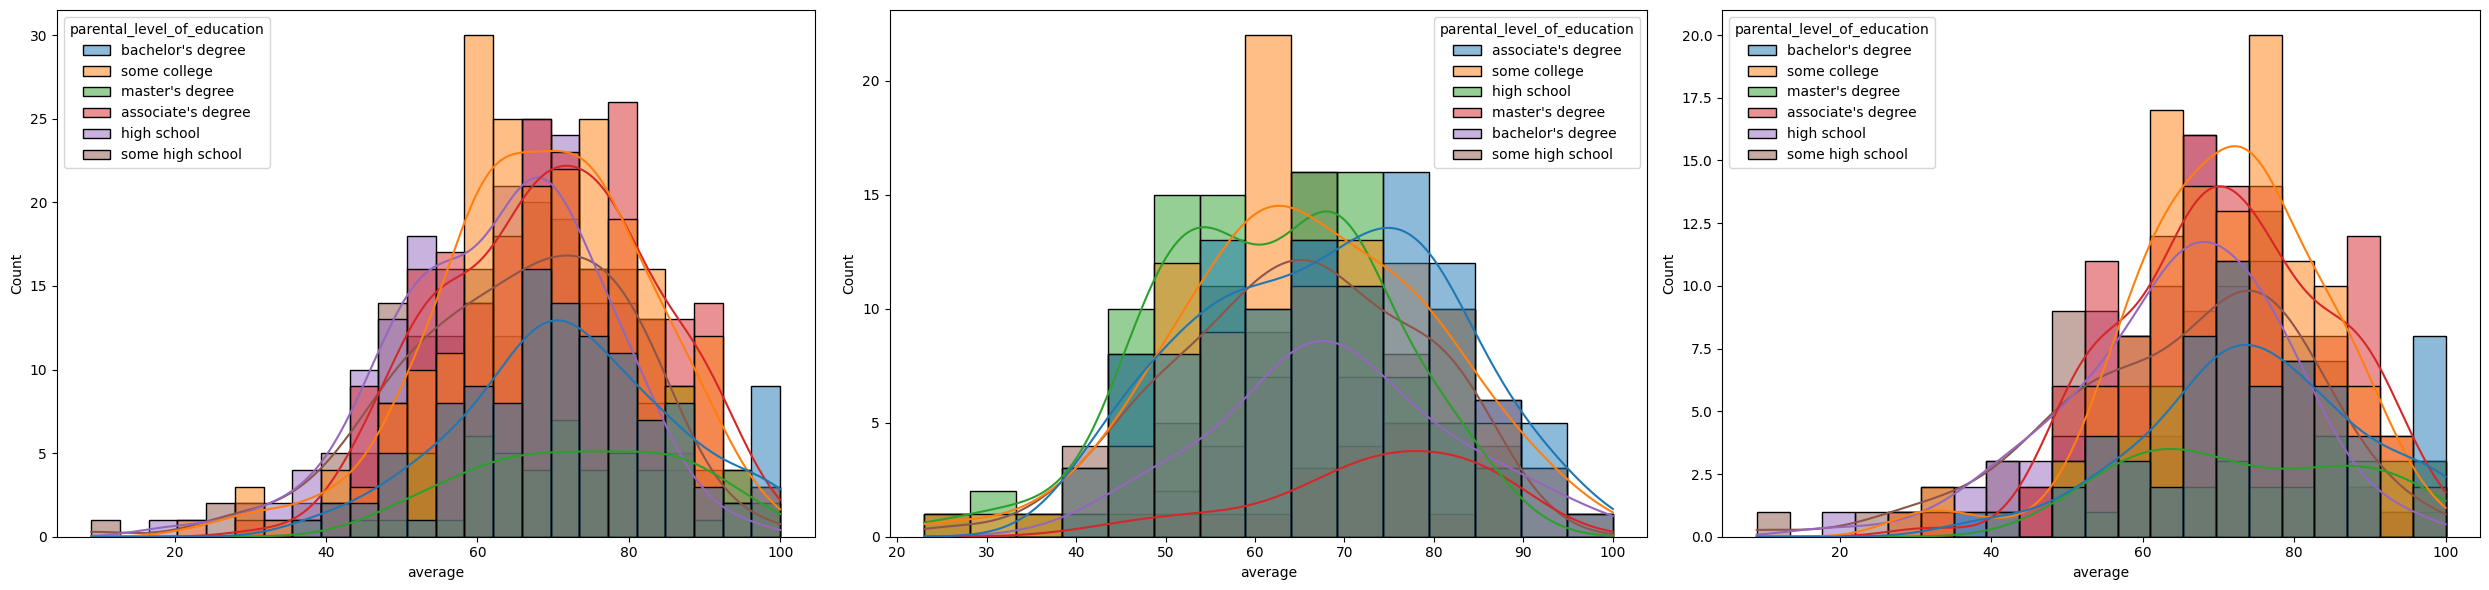

In [23]:
plt.figure(figsize=(25, 6))

plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='parental_level_of_education')

plt.subplot(132)
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='parental_level_of_education')

plt.subplot(133)
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='parental_level_of_education')

plt.tight_layout()
plt.show()

In [24]:
print(df.columns.tolist())

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'total score', 'average']


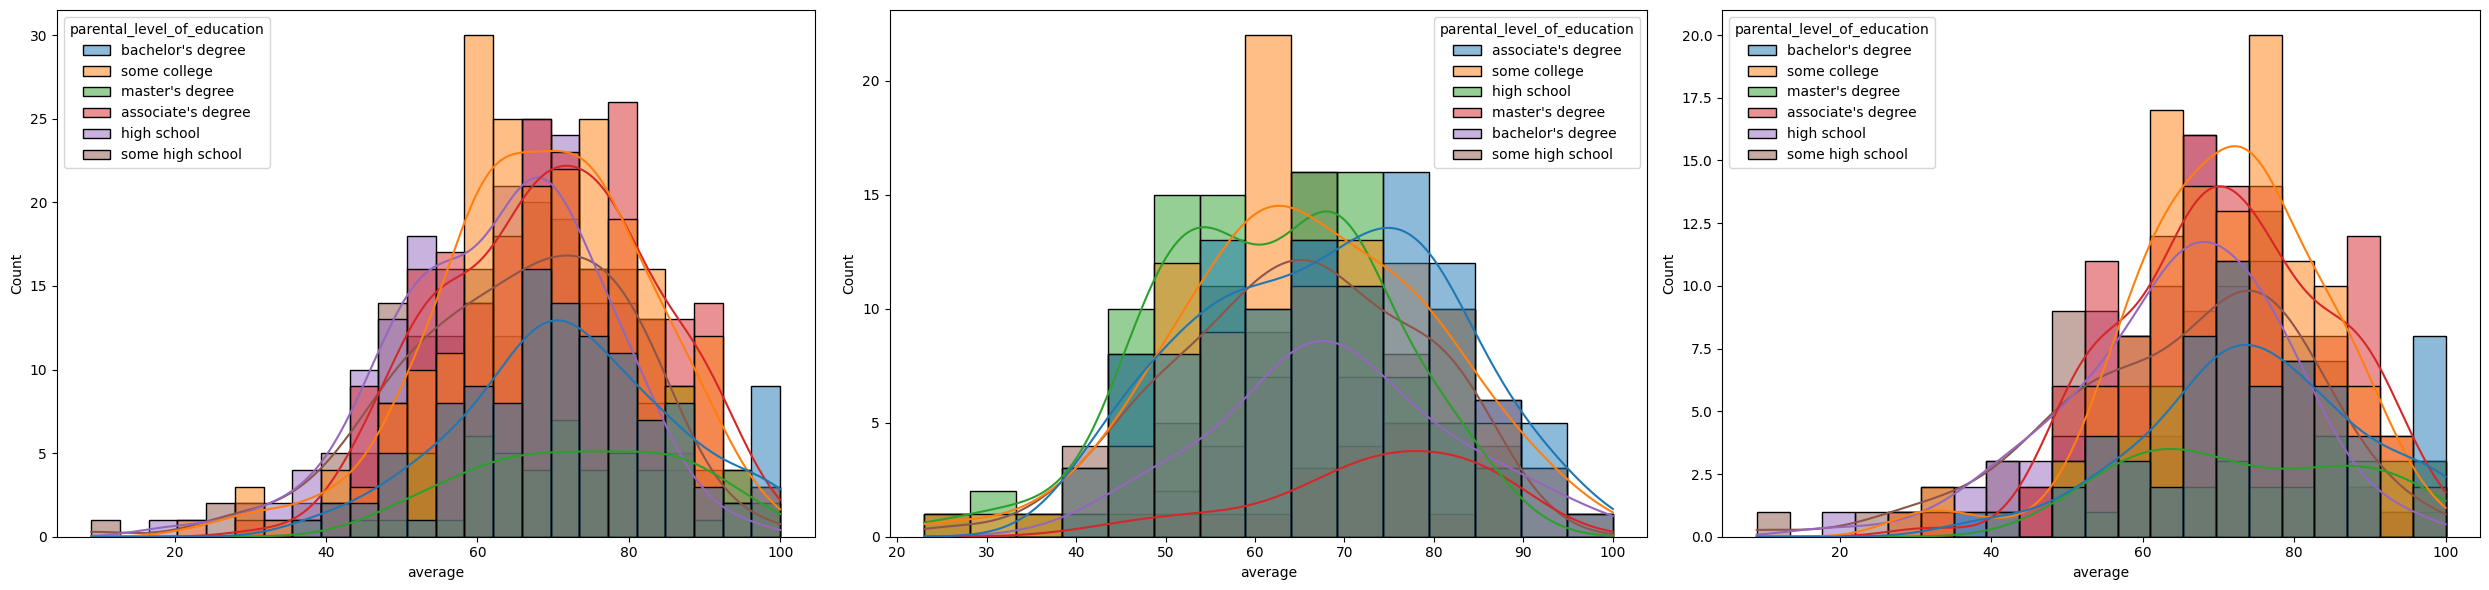

In [25]:
correct_column = 'parental_level_of_education' 

fig, axes = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df, x='average', kde=True, hue=correct_column, ax=axes[0])
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue=correct_column, ax=axes[1])
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue=correct_column, ax=axes[2])

plt.tight_layout()
plt.show()

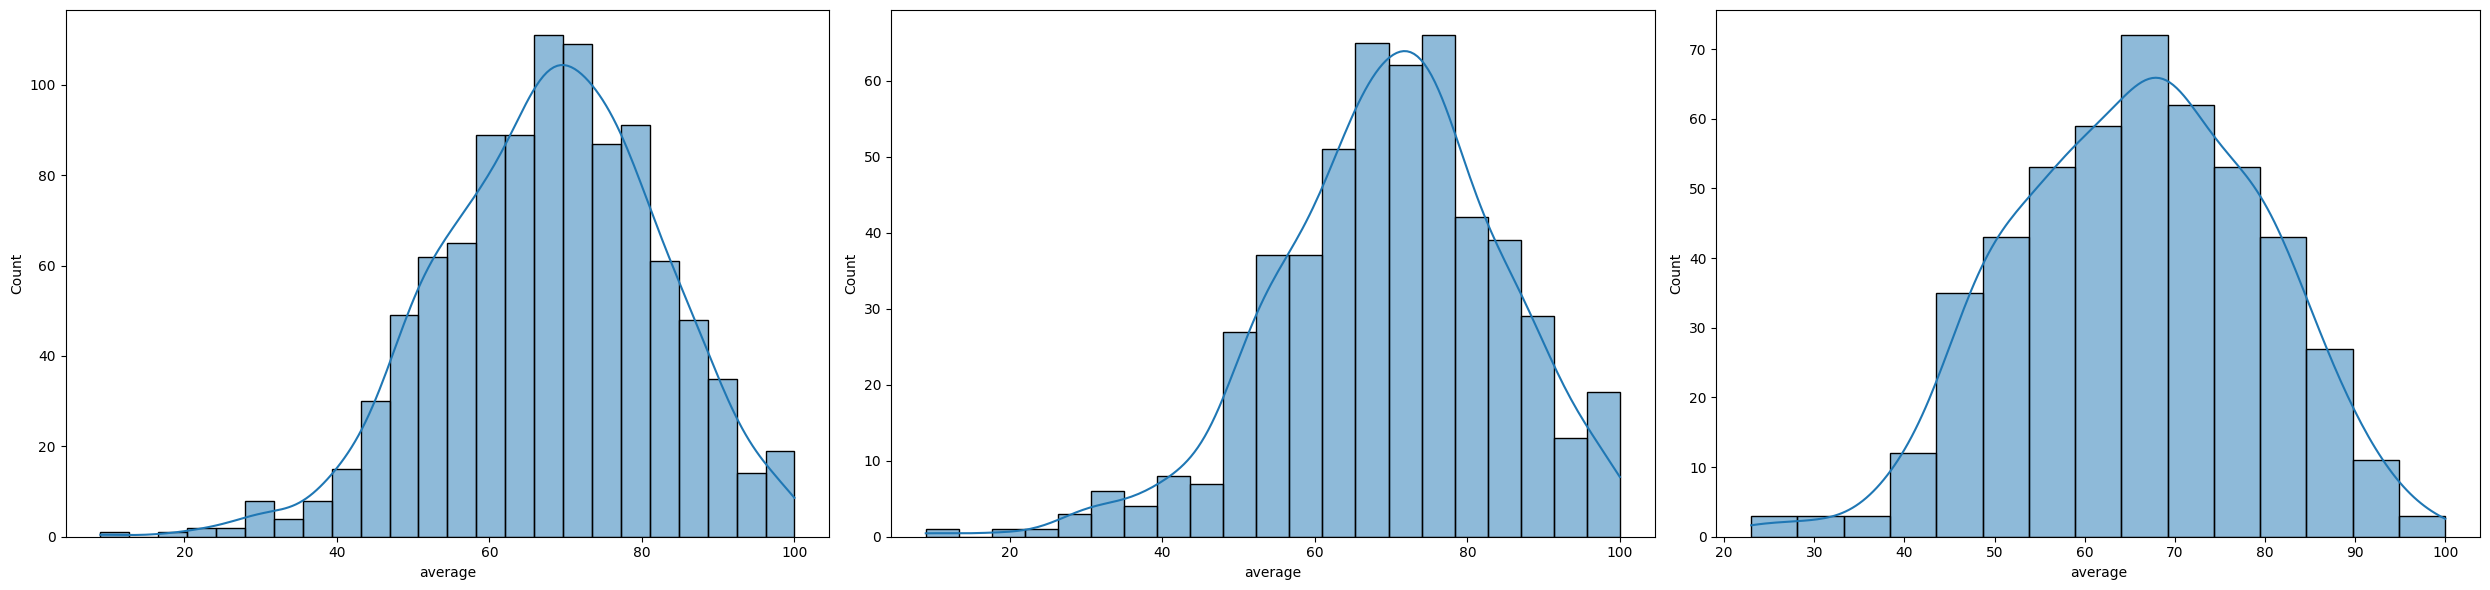

In [26]:
plt.subplots(1,3,figsize=(25,6))

plt.subplot(131) 
sns.histplot(data=df, x='average', kde=True)

plt.subplot(132) 
sns.histplot(data=df[df.gender=='female'], x='average', kde=True)

plt.subplot(133) 
sns.histplot(data=df[df.gender=='male'], x='average', kde=True)

plt.tight_layout()
plt.show()

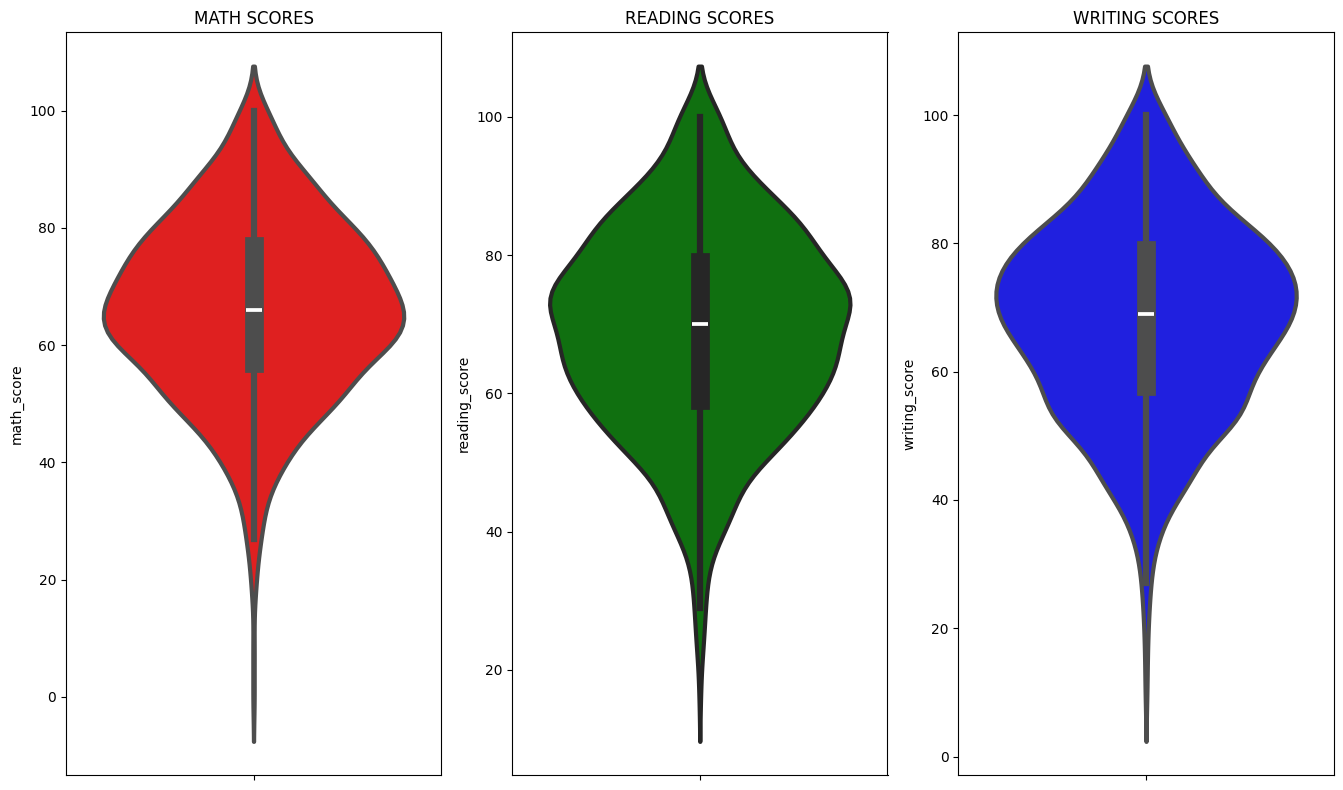

In [27]:
plt.figure(figsize=(18,8))

plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score', data=df, color='red', linewidth=3)

plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score', data=df, color='green', linewidth=3)

plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score', data=df, color='blue', linewidth=3)

plt.tight_layout()
plt.show()

##### Multivariate analysis using pieplot

In [28]:
df.columns = df.columns.str.strip().str.lower()

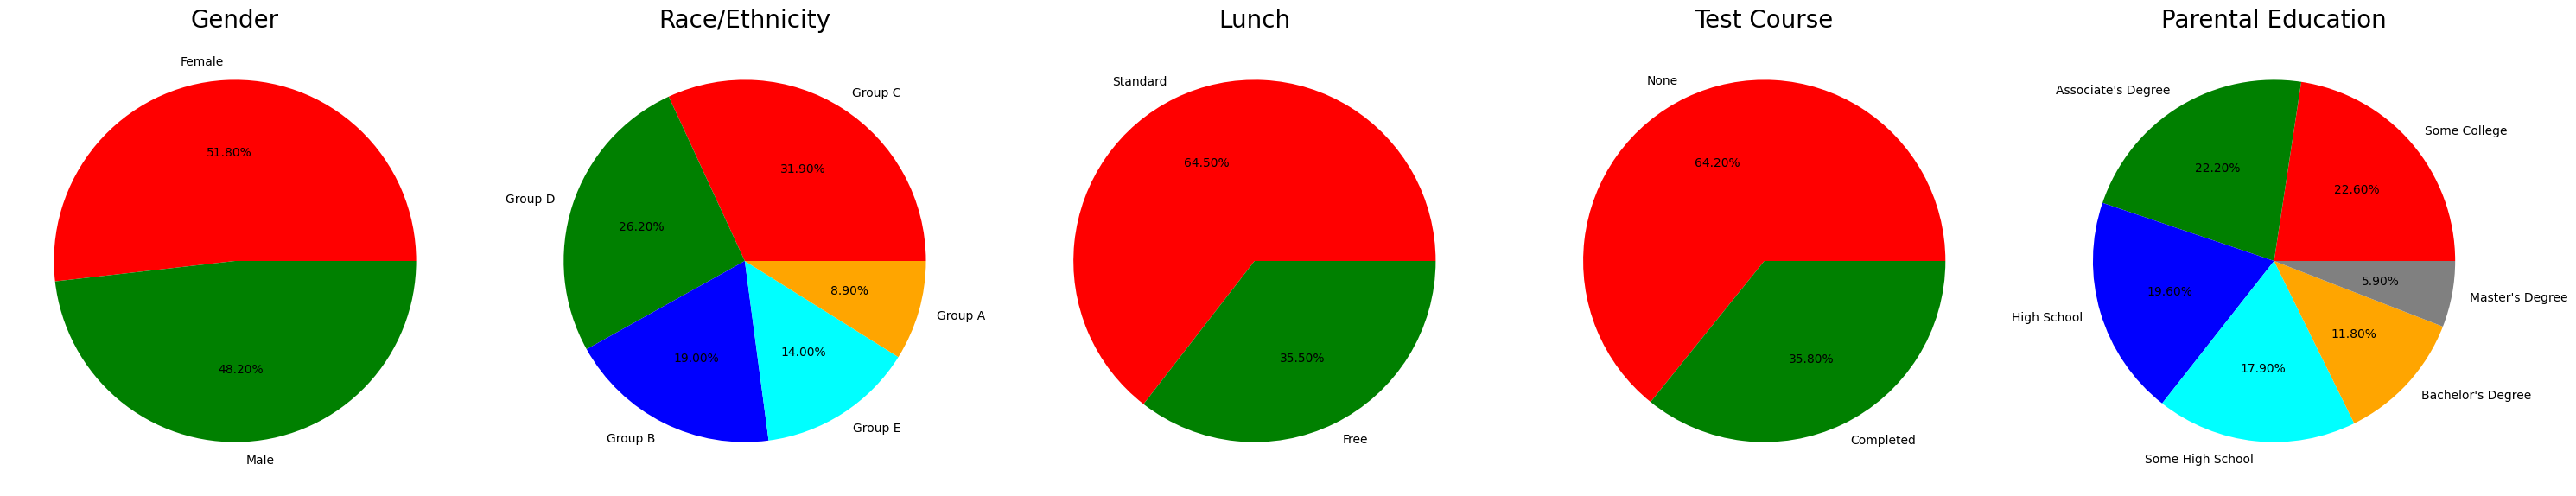

In [29]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (30, 12)

# ── Chart 1: Gender ──────────────────────────────────────────
plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
color = ['red', 'green']
plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

# ── Chart 2: Race/Ethnicity ──────────────────────────────────
plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()        
labels = ['Group C', 'Group D', 'Group B', 'Group E', 'Group A']
color = ['red', 'green', 'blue', 'cyan', 'orange']
plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')

# ── Chart 3: Lunch ───────────────────────────────────────────
plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = ['Standard', 'Free']
color = ['red', 'green']
plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

# ── Chart 4: Test Preparation Course ────────────────────────
plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts() 
labels = ['None', 'Completed']
color = ['red', 'green']
plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Test Course', fontsize=20)
plt.axis('off')

# ── Chart 5: Parental Level of Education ────────────────────
plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()  # ← underscores
labels = ["Some College", "Associate's Degree", "High School",
          "Some High School", "Bachelor's Degree", "Master's Degree"]
color = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']
plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
print(df.columns.tolist())

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'total score', 'average']


**Insights:**
* Number of Male and female students is almost equal
* Number of students are greatest in Group C
* Number of students who have standard lunch are greater
* Number of students who have not  enrolled in any test prepation cpourse is greater
* number of studnets whose parental educationb is "Some College' is greater followed closely by "Associate's Degree"

#### feature Wise Visualization
#### GENDER COLUMN
* How is distribution of Gender ?
* Gender has any impact on student's performance ?

##### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

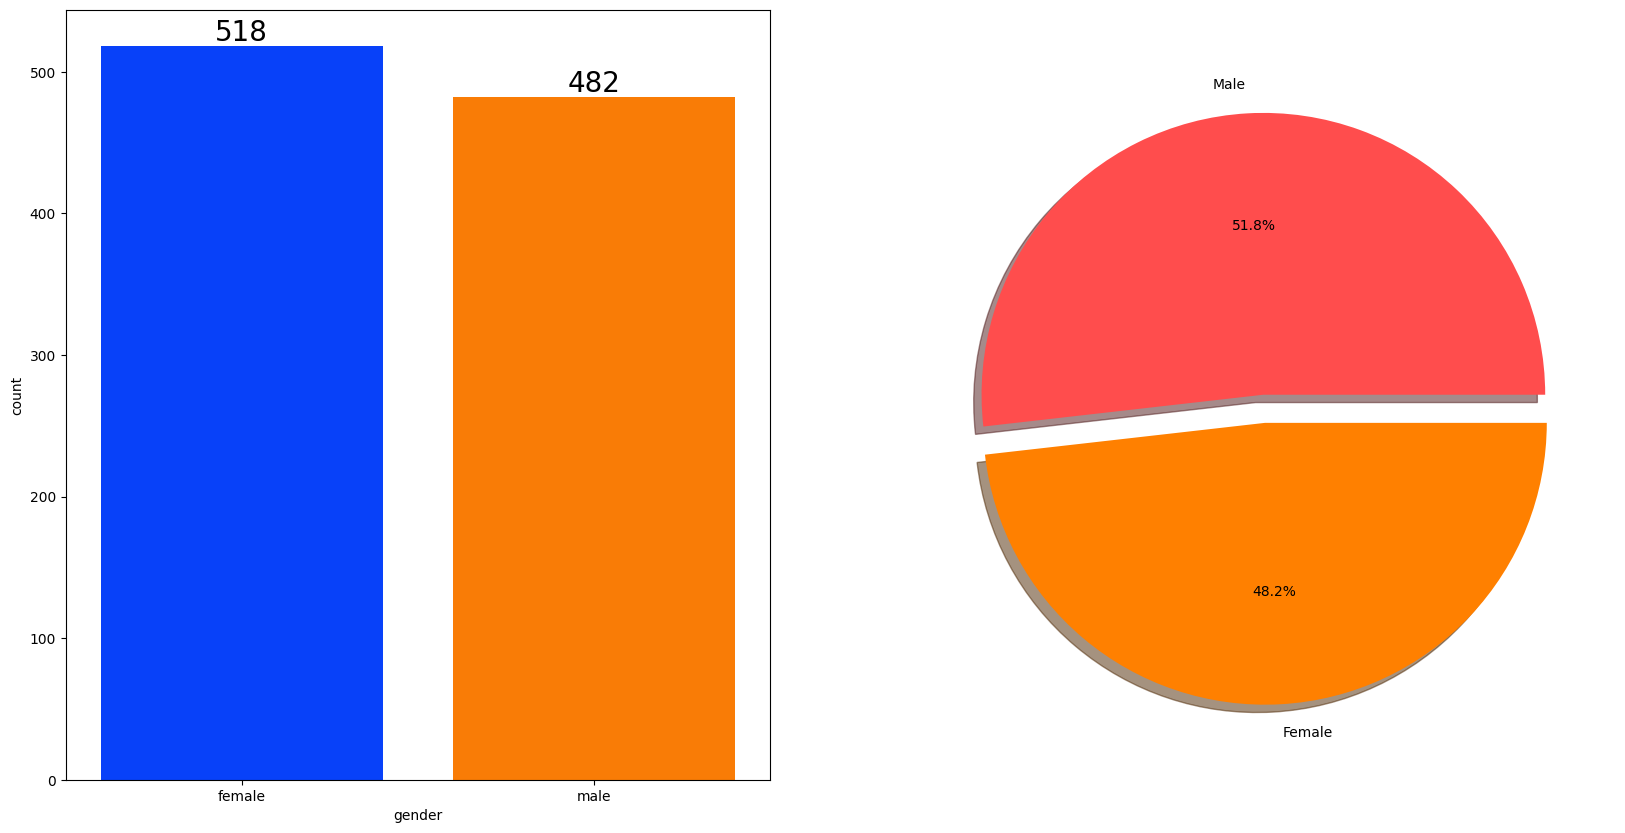

In [31]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

##### Insights
* Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

##### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [32]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


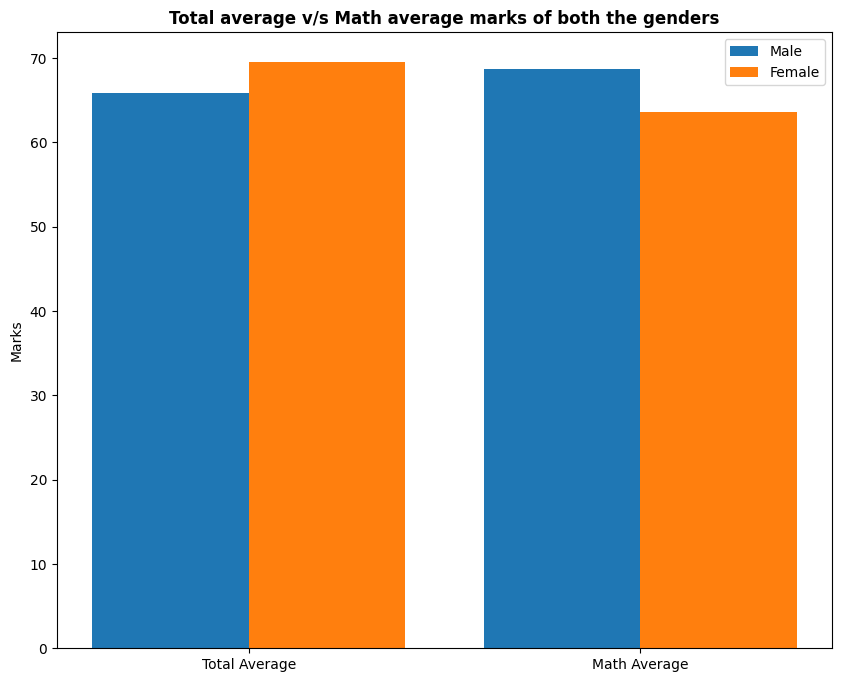

In [33]:
plt.figure(figsize=(10, 8))
X = ['Total Average','Math Average']

female_scores = [gender_group['average']['female'], gender_group['math_score']['female']]
male_scores = [gender_group['average']['male'], gender_group['math_score']['male']]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

##### Insights
* On an average females have a better overall score than men.
* whereas males have scored higher in Maths.
##### RACE/EHNICITY COLUMN
* How is Group wise distribution ?
* Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)


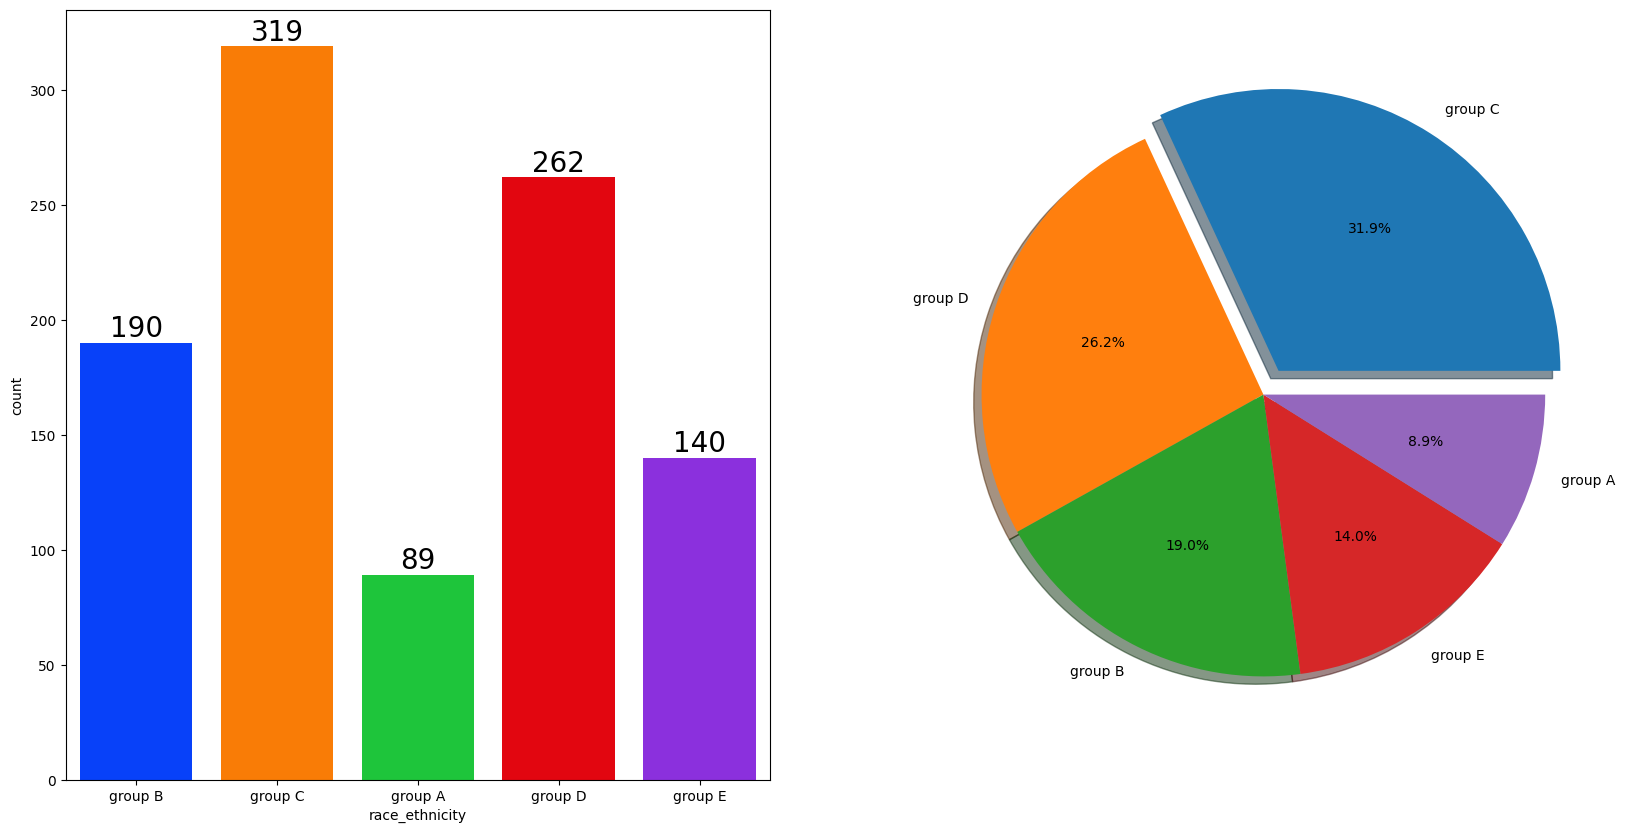

In [34]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   


##### Insights
* Most of the student belonging from group C /group D.
* Lowest number of students belong to groupA.
#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )



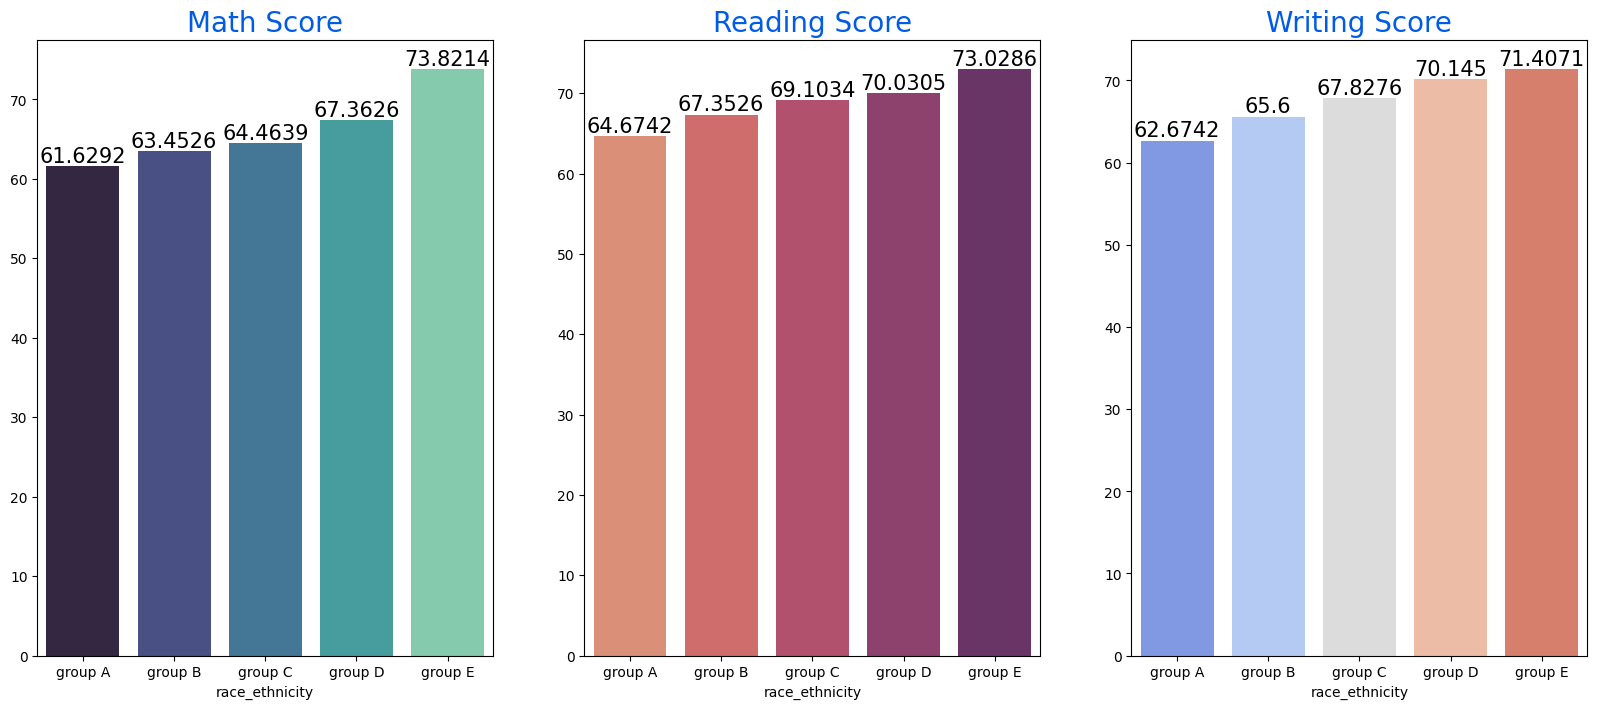

In [35]:
Group_data2 = df.groupby('race_ethnicity')
f, ax = plt.subplots(1, 3, figsize=(20, 8))

sns.barplot(x=Group_data2['math_score'].mean().index, y=Group_data2['math_score'].mean().values, palette='mako', ax=ax[0])
ax[0].set_title('Math Score', color='#005ce6', size=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index, y=Group_data2['reading_score'].mean().values, palette='flare', ax=ax[1])
ax[1].set_title('Reading Score', color='#005ce6', size=20)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index, y=Group_data2['writing_score'].mean().values, palette='coolwarm', ax=ax[2])
ax[2].set_title('Writing Score', color='#005ce6', size=20)

for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=15)
plt.show()

##### Insights
* Group E students have scored the highest marks.
* Group A students have scored the lowest marks.
* Students from a lower Socioeconomic status have a lower avg in all course subjects
##### PARENTAL LEVEL OF EDUCATION COLUMN
What is educational background of student's parent ?
Is parental education has any impact on student's performance ?
#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

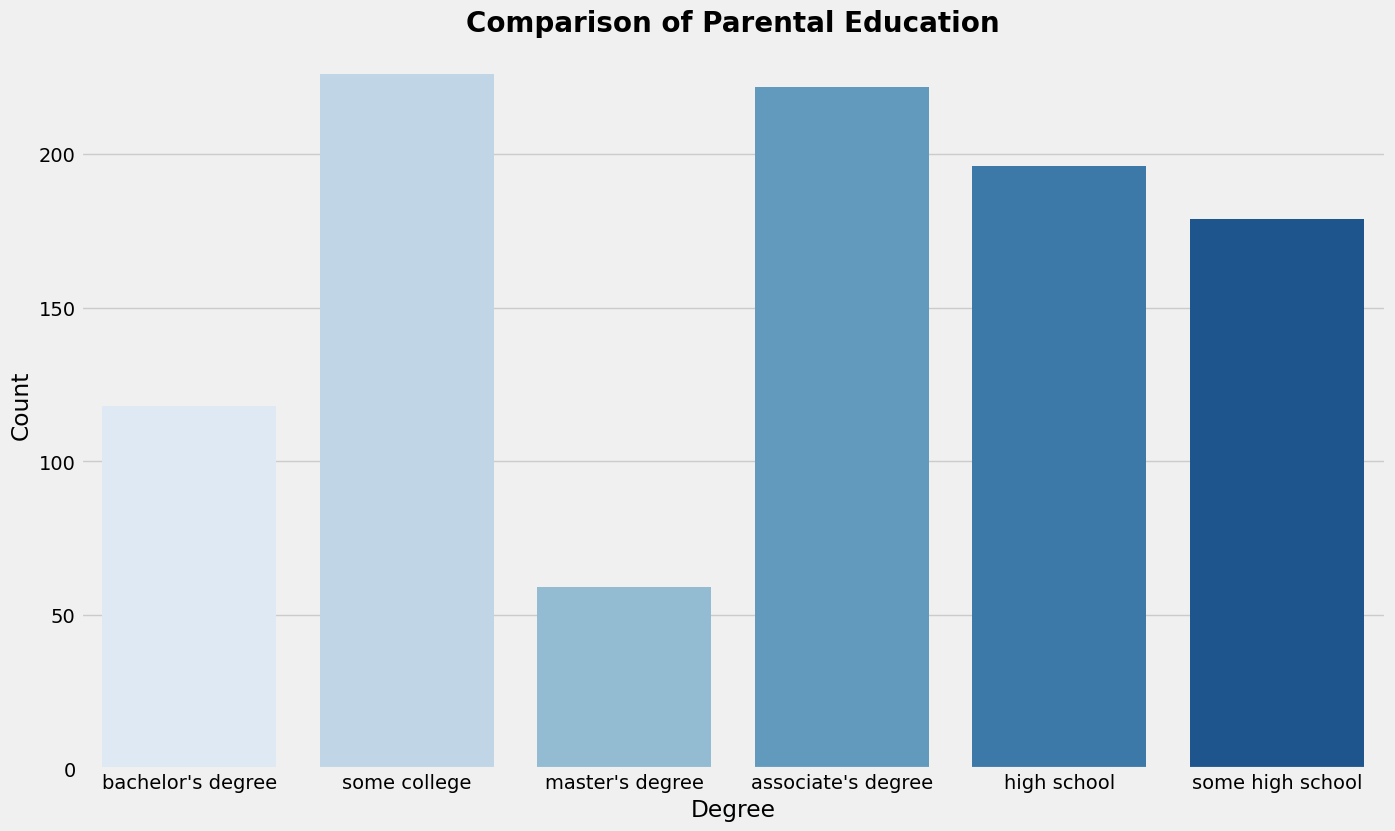

In [36]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(x='parental_level_of_education', data=df, palette='Blues')
plt.title('Comparison of Parental Education', fontweight='bold', fontsize=20)
plt.xlabel('Degree')
plt.ylabel('Count')
plt.show()


##### Insights
* Largest number of parents are from some college.
#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance!) 
* Largest number of parents are from some college.
BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

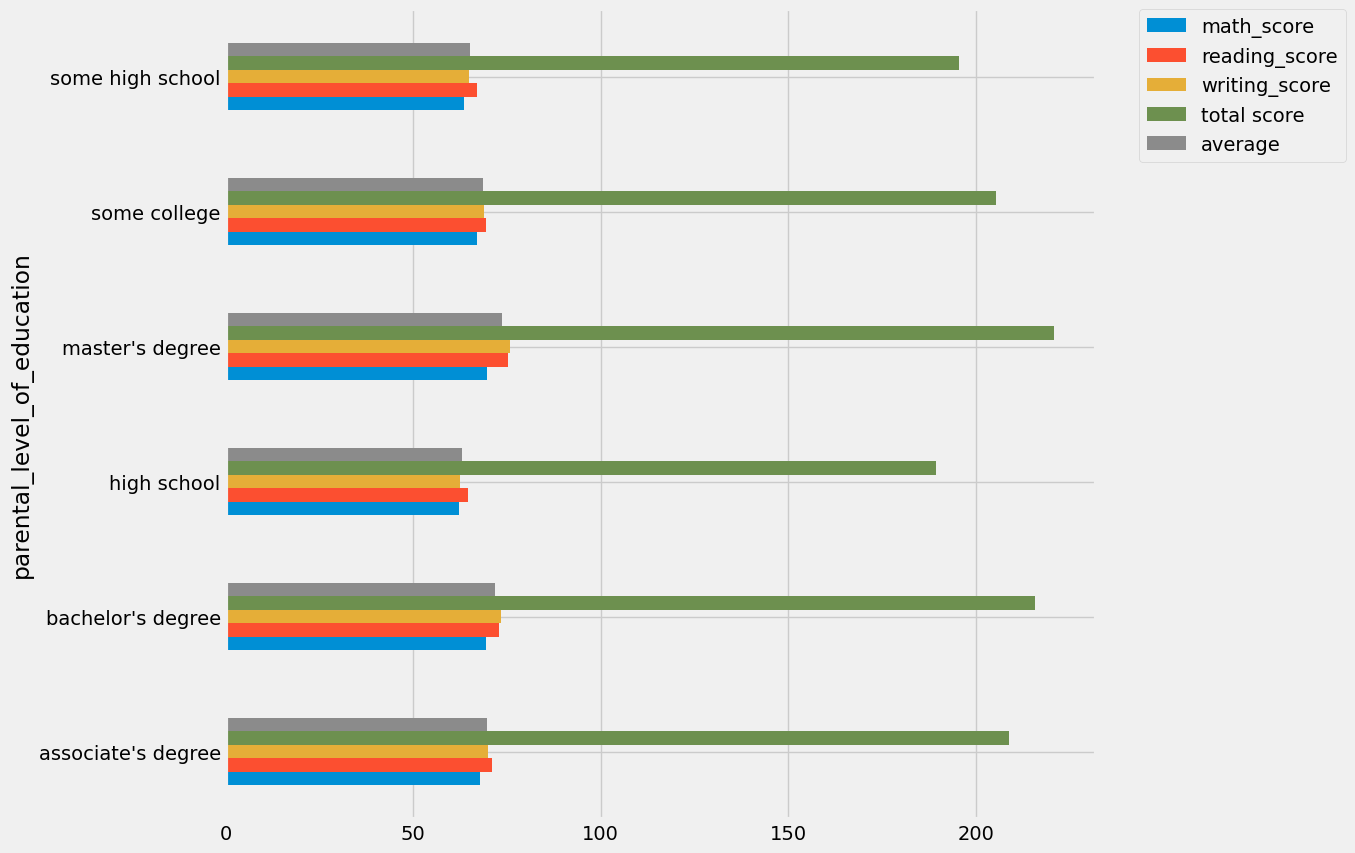

In [37]:
df.groupby('parental_level_of_education').agg('mean', numeric_only=True).plot(kind='barh', figsize=(10, 10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

##### Insights
* The score of student whose parents possess master and bachelor level education are higher than others.
#### LUNCH COLUMN
* Which type of lunch is most common amoung students ?
* What is the effect of lunch type on test results?
#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

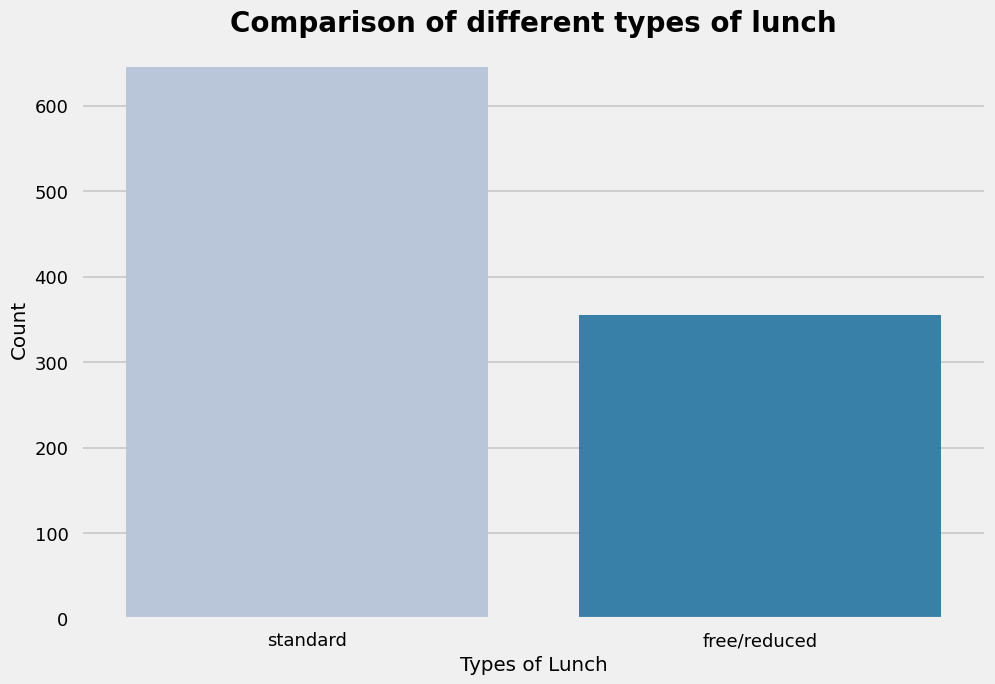

In [38]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(x='lunch', data=df, palette='PuBu')
plt.title('Comparison of different types of lunch', fontweight='bold', fontsize=20)
plt.xlabel('Types of Lunch')
plt.ylabel('Count')
plt.show()

##### Insights
* Students being served Standard lunch was more than free lunch
#### BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

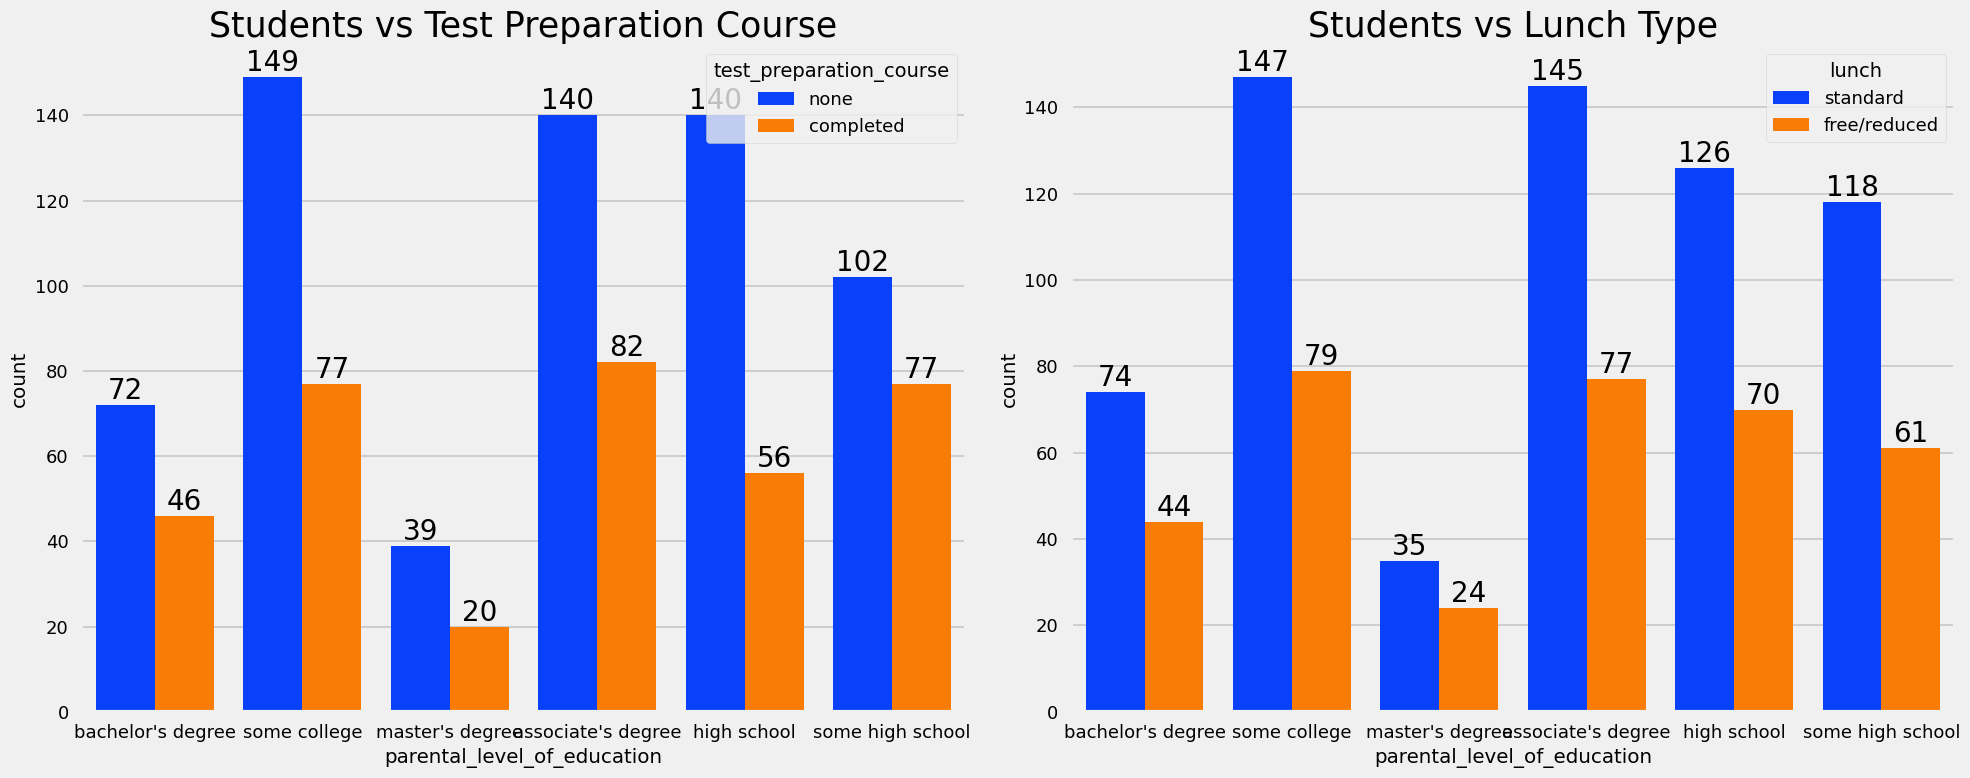

In [39]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.countplot(x='parental_level_of_education', data=df, palette='bright', 
              hue='test_preparation_course', saturation=0.95, ax=ax[0])
ax[0].set_title('Students vs Test Preparation Course', color='black', size=25)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

sns.countplot(x='parental_level_of_education', data=df, palette='bright', 
              hue='lunch', saturation=0.95, ax=ax[1])
ax[1].set_title('Students vs Lunch Type', color='black', size=25)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=20)

plt.tight_layout()
plt.show()

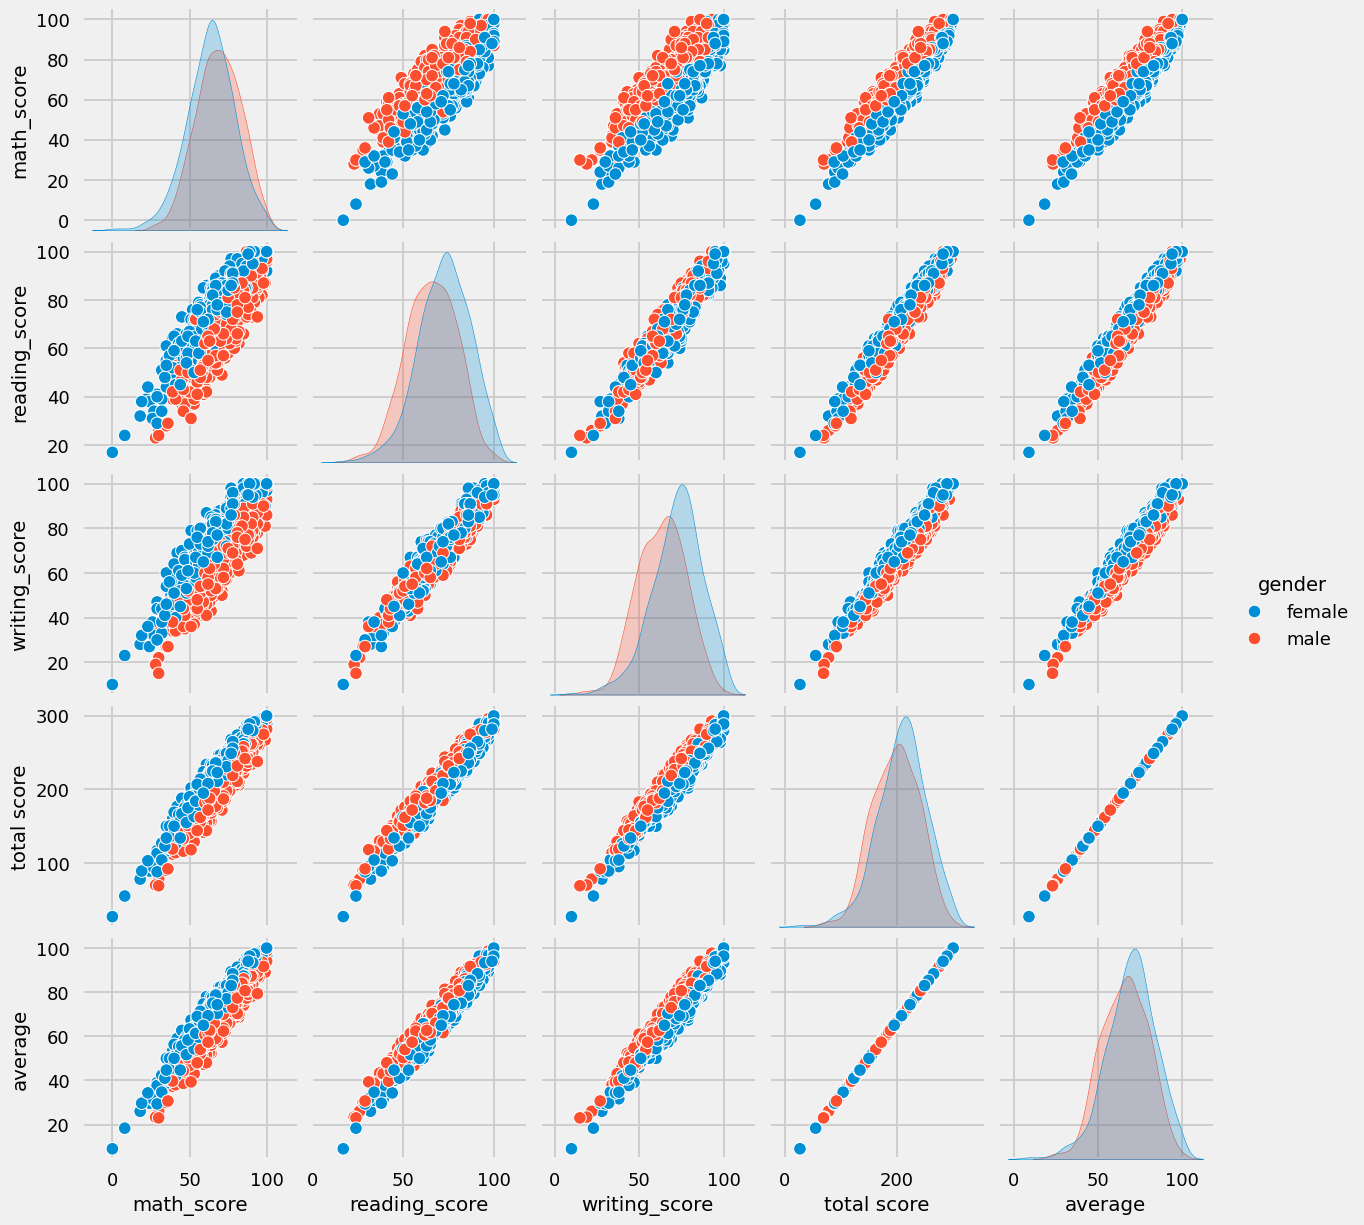

In [40]:
sns.pairplot(df,hue = 'gender')
plt.show()

##### Insigts
* from the above plots it is clea that all the scores increase linearly with each other.
#### Conclusion
* Student's Performance is related with lunch ,rac,parent level eduction
* Female lead in pass percentage and also are top_score
* Student's Performance is not much related with test preparation course
* Fining preparation course is benefitial.